# LISTA 05 AMA

#### Aluno: Jônatas Fernandes Silva
#### Matrícula: 603243

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)

#### Montando drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


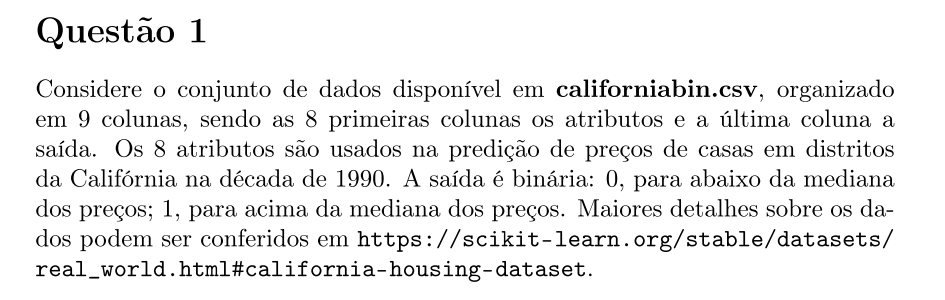

#### Carregando dados

In [3]:
df = pd.read_csv('/content/californiabin.csv', header=None)

In [4]:
X = df.iloc[:, :8].values
y = df.iloc[:, 8].values

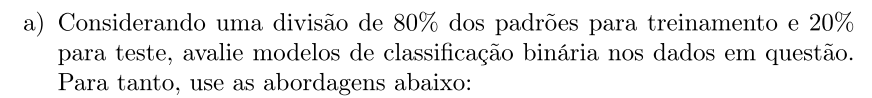

#### Data split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

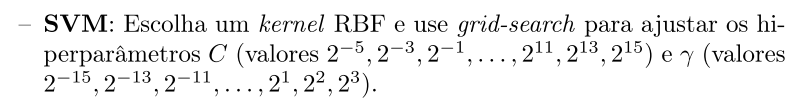

#### Treinamento SVM

In [7]:
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

##### Valores dos hiperparâmetros

In [9]:
c_range = [2**i for i in range(-5, 16, 2)]
gamma_range = [2**i for i in range(-15, 4, 2)]

In [10]:
param_grid_svm = {
    'svm__C': c_range,
    'svm__gamma': gamma_range
}

##### Grid SVM

In [11]:
grid_svm = GridSearchCV(
    pipeline_svm,
    param_grid=param_grid_svm,
    cv=10,
    scoring='accuracy',
    n_jobs=1
)
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
print(f"Melhores hiperparâmetros SVM: C = {grid_svm.best_params_['svm__C']}, gamma = {grid_svm.best_params_['svm__gamma']}")

Melhores hiperparâmetros SVM: C = 32768, gamma = 0.001953125


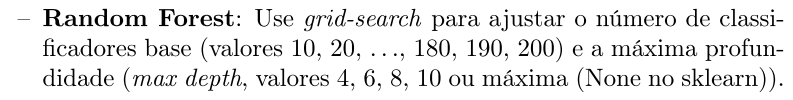

#### Treinamento do Random Forest

In [12]:
pipeline_rf = Pipeline([
    ('rf', RandomForestClassifier(random_state=42))
])

##### Hiperparâmetros do Radom Forest

In [13]:
n_estimators_range = list(range(10, 201, 10))
max_depth_range = [4, 6, 8, 10, None]

##### Grid Random Forest

In [14]:
param_grid_rf = {
    'rf__n_estimators': n_estimators_range,
    'rf__max_depth': max_depth_range
}

In [15]:
grid_rf = GridSearchCV(
    pipeline_rf,
    param_grid=param_grid_rf,
    cv=10,
    scoring='accuracy',
    n_jobs=-1
)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print(f"Melhores hiperparâmetros Random Forest: n_estimators = {grid_rf.best_params_['rf__n_estimators']}, max_depth = {grid_rf.best_params_['rf__max_depth']}")

Melhores hiperparâmetros Random Forest: n_estimators = 60, max_depth = None


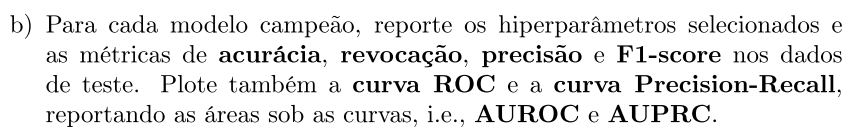

In [16]:
models = {
    'SVM (RBF)': best_svm,
    'Random Forest': best_rf
}

metrics_summary = {}

In [17]:
for name, model in models.items():
    # Predições
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    # Métricas
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Curva ROC e AUROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auroc = auc(fpr, tpr)

    # Curva Precision-Recall e AUPRC
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    auprc = average_precision_score(y_test, y_prob)

    metrics_summary[name] = {
        'Acurácia': acc, 'Revocação': rec, 'Precisão': prec, 'F1-Score': f1,
        'AUROC': auroc, 'AUPRC': auprc,
        'fpr': fpr, 'tpr': tpr,
        'precision_vals': precision_vals, 'recall_vals': recall_vals
    }

#### Métricas

In [18]:
for name, metrics in metrics_summary.items():
    print(f"\nModelo: {name}")
    print(f"  Acurácia:  {metrics['Acurácia']:.4f}")
    print(f"  Revocação: {metrics['Revocação']:.4f}")
    print(f"  Precisão:  {metrics['Precisão']:.4f}")
    print(f"  F1-Score:  {metrics['F1-Score']:.4f}")
    print(f"  AUROC:     {metrics['AUROC']:.4f}")
    print(f"  AUPRC:     {metrics['AUPRC']:.4f}")


Modelo: SVM (RBF)
  Acurácia:  0.8450
  Revocação: 0.8400
  Precisão:  0.8485
  F1-Score:  0.8442
  AUROC:     0.9301
  AUPRC:     0.9336

Modelo: Random Forest
  Acurácia:  0.8775
  Revocação: 0.8500
  Precisão:  0.8995
  F1-Score:  0.8740
  AUROC:     0.9518
  AUPRC:     0.9523


#### Plot dos gráficos

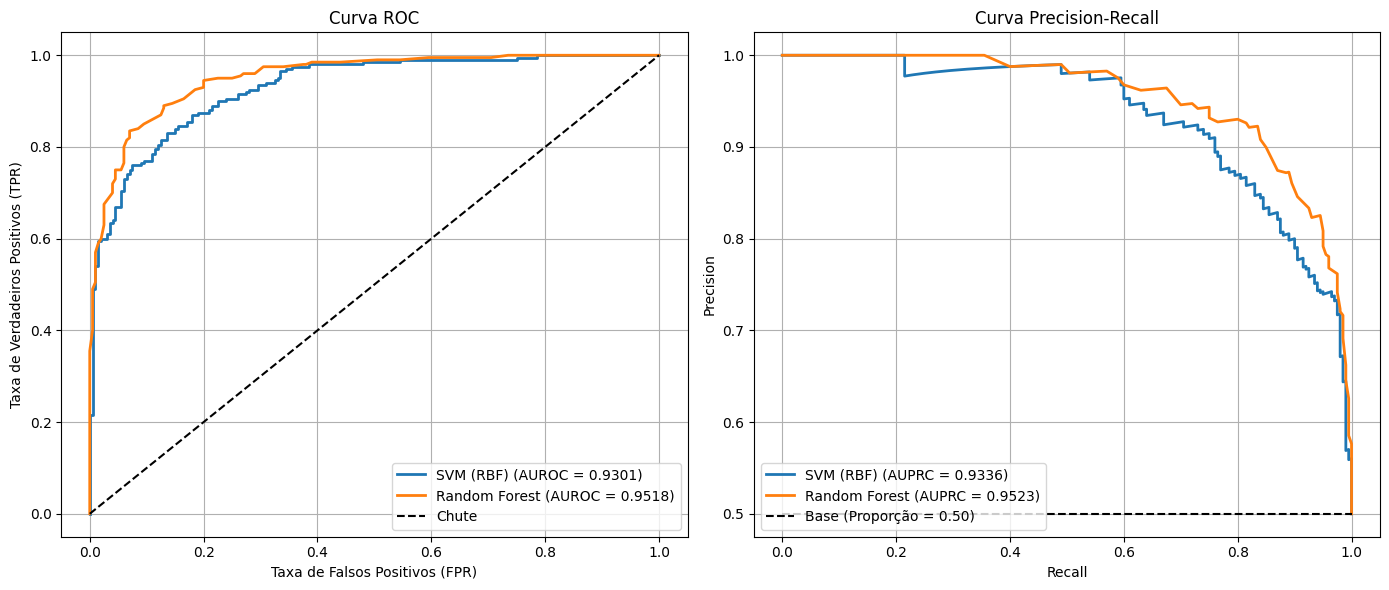

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for name, metrics in metrics_summary.items():
    ax1.plot(metrics['fpr'], metrics['tpr'], label=f"{name} (AUROC = {metrics['AUROC']:.4f})", linewidth=2)
ax1.plot([0, 1], [0, 1], 'k--', label='Chute')
ax1.set_xlabel('Taxa de Falsos Positivos (FPR)')
ax1.set_ylabel('Taxa de Verdadeiros Positivos (TPR)')
ax1.set_title('Curva ROC')
ax1.legend(loc='lower right')
ax1.grid(True)

for name, metrics in metrics_summary.items():
    ax2.plot(metrics['recall_vals'], metrics['precision_vals'], label=f"{name} (AUPRC = {metrics['AUPRC']:.4f})", linewidth=2)

base_rate = np.sum(y_test) / len(y_test)
ax2.plot([0, 1], [base_rate, base_rate], 'k--', label=f'Base (Proporção = {base_rate:.2f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Curva Precision-Recall')
ax2.legend(loc='lower left')
ax2.grid(True)

plt.tight_layout()
plt.show()